<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
C:\Users\dd03\AppData\Local\Temp\ipykernel_2736\54546836.py:52: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('MSD ($\mathrm{m}^2$)', fontsize=22)


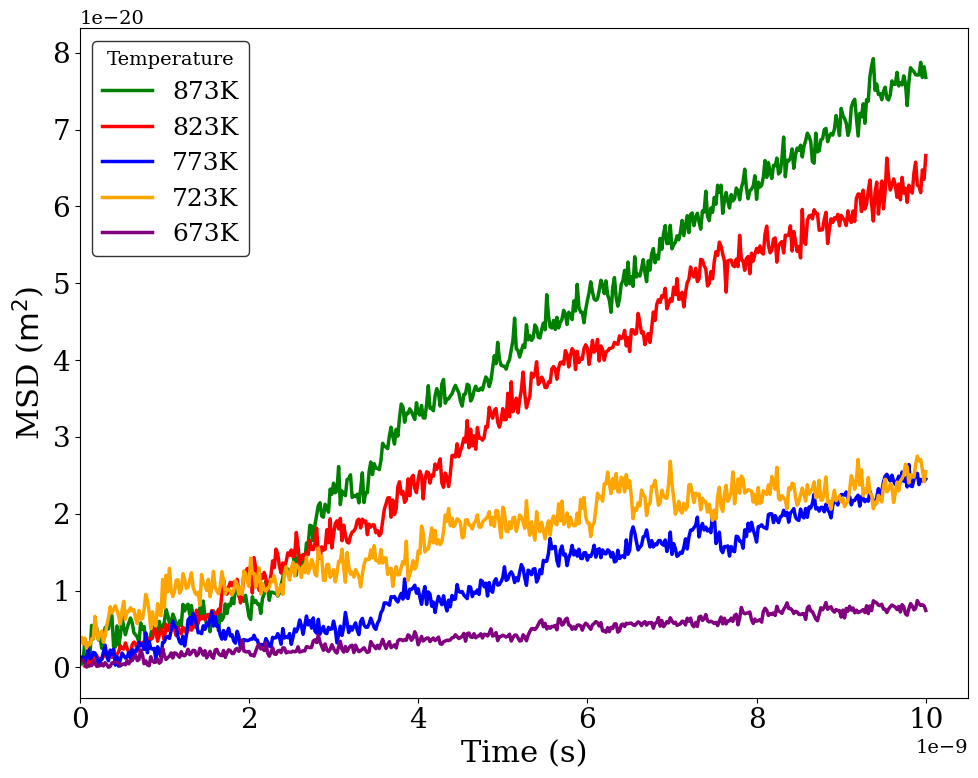


--- Diffusion Results (t >= 5000 ps) ---
   Temp         Slope             D        R2
0  873K  7.726160e-12  3.863080e-12  0.989187
1  823K  6.609648e-12  3.304824e-12  0.971119
2  773K  2.559097e-12  1.279549e-12  0.931906
3  723K  1.125172e-12  5.625862e-13  0.585476
4  673K  7.606090e-13  3.803045e-13  0.869213


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.ticker as ticker

# 1. Setup
excel_file = 'MSD_Edge_Vacancy.xlsx'
xl = pd.ExcelFile(excel_file)
sheets = xl.sheet_names # Assumed order: ['673K', '723K', '773K', '823K', '873K']

# Manual colors: Green (bottom/673K), Red, Blue, Orange, Purple
manual_colors = ['green', 'red', 'blue', 'orange', 'purple']

results = []

# Styling
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.family': 'serif', 'font.size': 14})

# 2. Processing and Plotting
for i, sheet in enumerate(sheets):
    df = pd.read_excel(excel_file, sheet_name=sheet)
    
    # Extract raw columns
    time_ps = df.iloc[:, 0]
    msd_raw = df.iloc[:, 1]
    
    # Convert Units to SI
    time_s = time_ps * 1e-12  # ps to s
    msd_m2 = msd_raw * 1e-20  # A^2 to m^2
    
    # 3. Filter for steady-state (t >= 5000 ps)
    mask = time_ps >= 4000
    time_fit = time_s[mask]
    msd_fit = msd_m2[mask]
    
    if len(time_fit) < 2: continue

    # Linear Regression (SI units)
    slope, intercept, r_value, p_value, std_err = linregress(time_fit, msd_fit)
    D_si = slope / 2
    
    results.append({'Temp': sheet, 'Slope': slope, 'D': D_si, 'R2': r_value**2})
    
    # 4. Plotting (Data only, NO fitting lines)
    color = manual_colors[i] if i < len(manual_colors) else None
    plt.plot(time_s, msd_m2, color=color, linewidth=2.5, label=sheet)

# 5. Formatting
plt.xlabel('Time (s)', fontsize=22)
plt.ylabel('MSD ($\mathrm{m}^2$)', fontsize=22)
plt.xticks(fontsize=20) # Adjust this number to your preferred size
plt.yticks(fontsize=20) # Adjust this number to your preferred size

# X-axis: 1e-9 scientific notation
formatter_x = ticker.ScalarFormatter(useMathText=False)
formatter_x.set_scientific(True)
formatter_x.set_powerlimits((-9, -9))
plt.gca().xaxis.set_major_formatter(formatter_x)

# Y-axis: Scientific notation
formatter_y = ticker.ScalarFormatter(useMathText=False)
formatter_y.set_scientific(True)
formatter_y.set_powerlimits((0, 0)) 
plt.gca().yaxis.set_major_formatter(formatter_y)

# Legend
plt.legend(title='Temperature', loc='upper left', frameon=True, edgecolor='k', fontsize=18)

# --- CHANGE HERE: Removes the space at the start of the X-axis ---
plt.xlim(left=0) 
# plt.ylim(bottom=0) # Uncomment this if you also want the Y-axis to start exactly at 0

#plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save
plt.savefig('Edge_Dislocation_MSD.png', dpi=300)
plt.show()

# Print Results Table
results_df = pd.DataFrame(results)
print("\n--- Diffusion Results (t >= 5000 ps) ---")
print(results_df)